Performing graphical visualizations on the cleaned dataset to understand the data distribution clearly

In [26]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
BASE_DIR = r'D:\Personal_Projects\E-Commerce_dynamic_system'
sys.path.append(os.path.join(BASE_DIR, 'src'))

In [27]:
df=pd.read_csv(r'D:\Personal_Projects\E-Commerce_dynamic_system\data\processed\cleaned_products.csv',index_col=0)

In [28]:
from feature_engineering import engineer_all_features
df=engineer_all_features(df)

Univariate Analysis-Analysis on single column

In [29]:
df

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,listed_price,is_best_seller,is_sponsored,is_couponed,sustainability_badges,...,discounted_amount,discount_pct,value_score,demand_score,estimated_revenue,price_category,revenue_leakage_pct,premium_price_flag,price_vs_avg,review_credibility
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,0,1,0,0,...,69.32,43.597484,0.051293,0.0030,26904.0,Mid-range,43.597484,0,0.532177,27.276110
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,0,1,0,1,...,6.00,37.523452,0.430430,0.0600,59940.0,Budget,37.523452,0,0.059282,33.570544
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,0,1,0,1,...,35.00,10.028653,0.014650,0.0200,628000.0,Premium,10.028653,0,1.863333,36.897778
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,77.00,56.99,1,0,0,1,...,-20.01,-35.111423,0.059740,0.1000,770000.0,Mid-range,0.000000,1,0.456932,48.244887
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,77.00,56.99,0,0,0,1,...,-20.01,-35.111423,0.062338,0.1000,770000.0,Mid-range,0.000000,1,0.456932,49.318424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,56.99,0,0,0,1,...,-139.00,-243.902439,0.025512,0.0010,19599.0,Premium,0.000000,1,1.163040,3.465736
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,56.99,0,0,0,1,...,-33.00,-57.904896,0.046672,0.0020,17998.0,Mid-range,0.000000,1,0.534017,12.786994
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,56.99,0,0,0,1,...,-843.00,-1479.206878,0.004778,0.0005,44999.5,Premium,0.000000,1,5.340704,17.459905
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,0,0,0,1,...,5.59,34.981227,0.452358,0.0050,5195.0,Budget,34.981227,0,0.061656,41.680881


Price Distribution Analysis using histogram

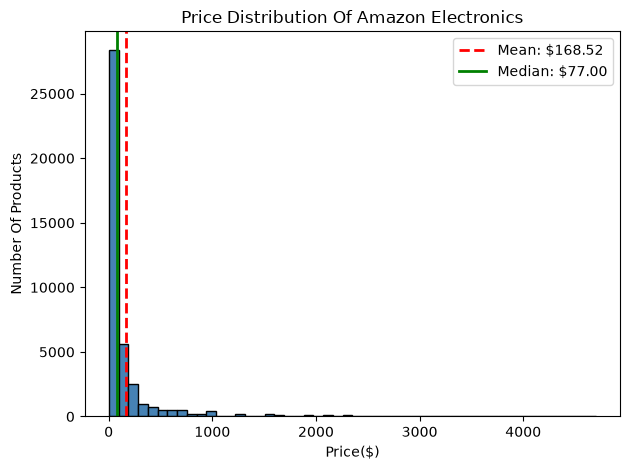

<Figure size 640x480 with 0 Axes>

In [30]:
plt.hist(df['current/discounted_price'],bins=50,color='steelblue',edgecolor='black')
mean_price = df['current/discounted_price'].mean()
median_price = df['current/discounted_price'].median()
# Mean line
plt.axvline(mean_price,color='red', linestyle='--',linewidth=2,label=f'Mean: ${mean_price:.2f}')
# Median line
plt.axvline(median_price,color='green',linestyle='-',linewidth=2,label=f'Median: ${median_price:.2f}')
plt.title("Price Distribution Of Amazon Electronics")
plt.xlabel("Price($)")
plt.ylabel("Number Of Products")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\price_distribution.png',
            dpi=300, bbox_inches='tight')

Rating Distribution

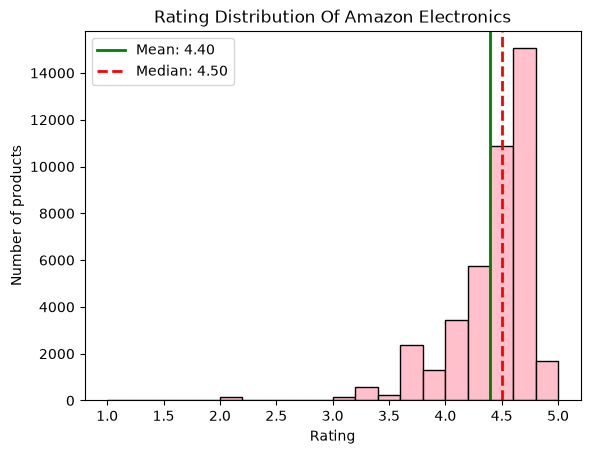

In [31]:

plt.hist(df['rating'],bins=20,color='pink',edgecolor='black')
mean_rating=df['rating'].mean()
median_rating=df['rating'].median()
plt.axvline(mean_rating,linestyle='-',linewidth=2,color='green',label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating,linestyle='--',linewidth=2,color='red',label=f'Median: {median_rating:.2f}')
plt.title("Rating Distribution Of Amazon Electronics")
plt.xlabel("Rating")
plt.ylabel("Number of products")
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\rating_distribution.png',
            dpi=300, bbox_inches='tight')
plt.legend()

Discount Percentage Distribution

In [32]:
df.columns

Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'current/discounted_price', 'listed_price', 'is_best_seller',
       'is_sponsored', 'is_couponed', 'sustainability_badges', 'collected_at',
       'discounted_amount', 'discount_pct', 'value_score', 'demand_score',
       'estimated_revenue', 'price_category', 'revenue_leakage_pct',
       'premium_price_flag', 'price_vs_avg', 'review_credibility'],
      dtype='str')

In [33]:
df.loc[df['discount_pct']<0,['discounted_amount','discount_pct','current/discounted_price']].head(20)

,discounted_amount,discount_pct,current/discounted_price
3,-20.01,-35.111423,77.00
4,-20.01,-35.111423,77.00
5,-20.01,-35.111423,77.00
6,-20.01,-35.111423,77.00
7,-20.01,-35.111423,77.00
9,-20.01,-35.111423,77.00
11,-20.01,-35.111423,77.00
13,-193.00,-338.655905,249.99
14,-12.96,-22.740832,69.95
15,-20.01,-35.111423,77.00


In [34]:
(df['discount_pct']<0).sum()

np.int64(23654)

In [35]:
(df['discount_pct']<0).mean()*100

np.float64(56.790953398477825)

In [36]:
df[['listed_price', 'current/discounted_price']].describe()

,listed_price,current/discounted_price
count,41651.000000,41651.000000
mean,75.432252,168.515247
std,87.715638,316.766992
min,4.950000,2.490000
25%,56.990000,34.990000
50%,56.990000,77.000000
75%,56.990000,129.990000
max,999.990000,4699.000000


In [37]:
(df['listed_price'] > df['current/discounted_price']).mean() * 100

np.float64(43.20424479604331)

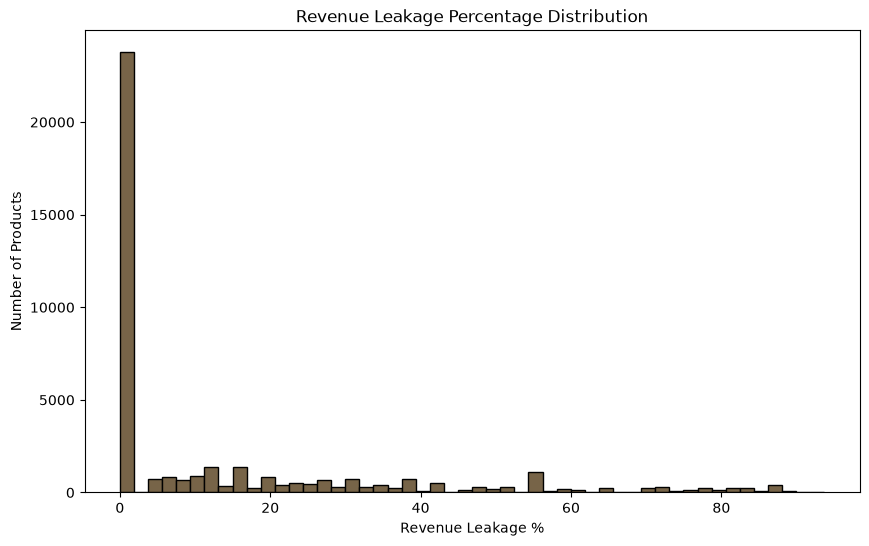

In [38]:
plt.figure(figsize=(10,6))
plt.hist(df['revenue_leakage_pct'],bins=50,color="#776448",edgecolor='black')
plt.title('Revenue Leakage Percentage Distribution')
plt.xlabel('Revenue Leakage %')
plt.ylabel('Number of Products')
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\revenue_leakage.png',
            dpi=300, bbox_inches='tight')

Price category piechart,to visualize the proportions of categories always use value_counts() which creates pandas series where counts.values → the actual numeric counts (how many times each category appears).
counts.index → the labels (the category names themselves).

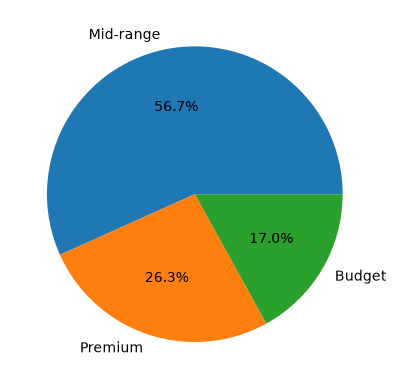

In [39]:
counts=df['price_category'].value_counts()
plt.pie(counts.values,labels=counts.index,autopct="%1.1f%%")
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\price_category.png',
            dpi=300, bbox_inches='tight')

Bivariate Analysis

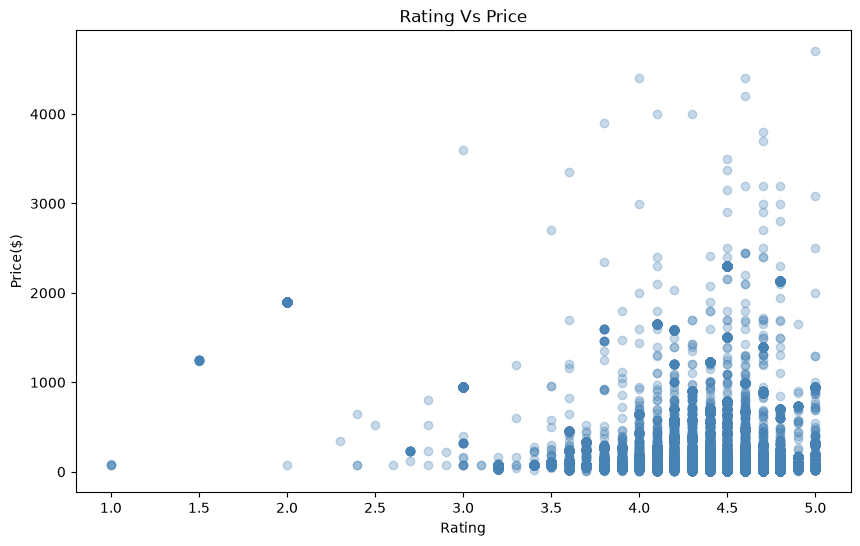

In [40]:
plt.figure(figsize=(10,6))
plt.scatter(df['rating'],df['current/discounted_price'],alpha=0.3,color='steelblue')
plt.title('Rating Vs Price')
plt.xlabel('Rating')
plt.ylabel('Price($)')
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\rating vs price.png',
            dpi=300, bbox_inches='tight')
plt.show()

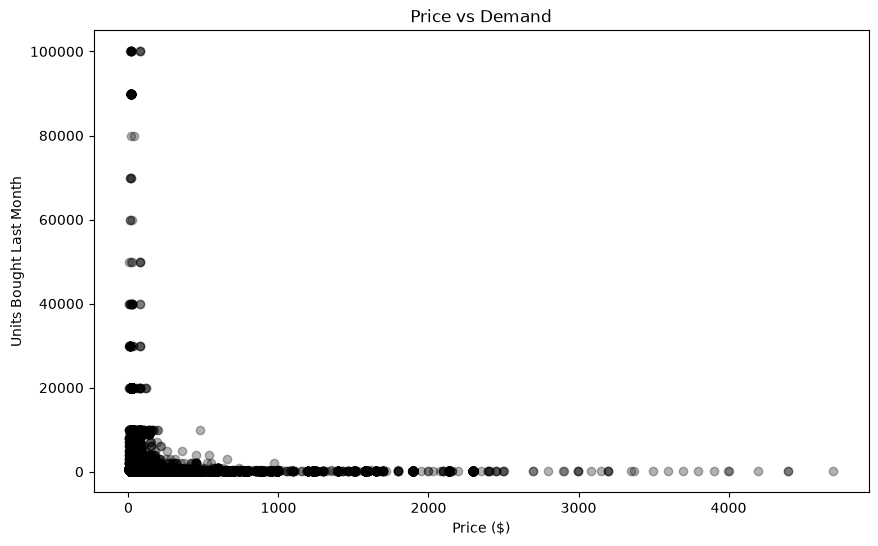

In [42]:
plt.figure(figsize=(10,6))
plt.scatter(df['current/discounted_price'],df['bought_in_last_month'],alpha=0.3,color='black')
plt.title('Price vs Demand')
plt.xlabel('Price ($)')
plt.ylabel('Units Bought Last Month')
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\price_vs_demand.png',
            dpi=300, bbox_inches='tight')
plt.show()

C:\Users\bharg\AppData\Local\Temp\ipykernel_21672\3881655364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_best_seller',y='current/discounted_price',data=df,palette='Set2')


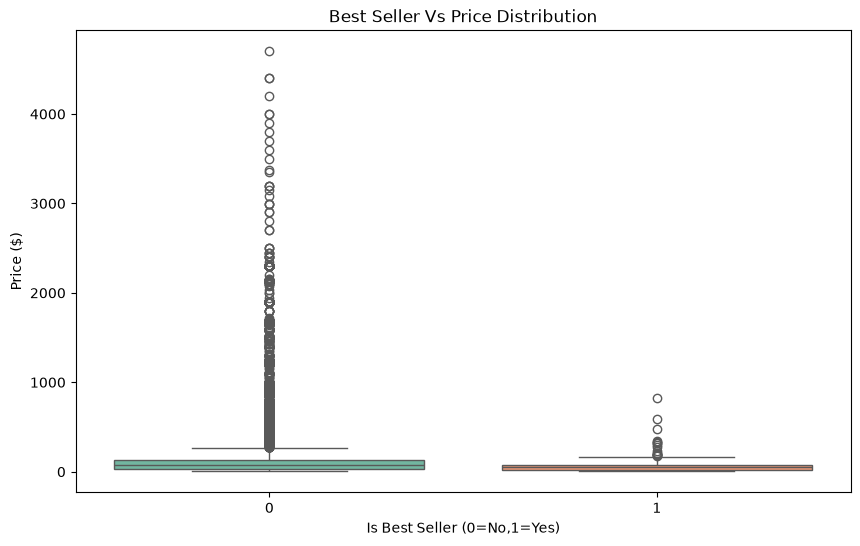

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='is_best_seller',y='current/discounted_price',data=df,palette='Set2')
plt.title('Best Seller Vs Price Distribution')
plt.xlabel('Is Best Seller (0=No,1=Yes)')
plt.ylabel('Price ($)')
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\best_seller vs price.png',
            dpi=300, bbox_inches='tight')

HeatMap shows which features related to price and helps select best features for ML model

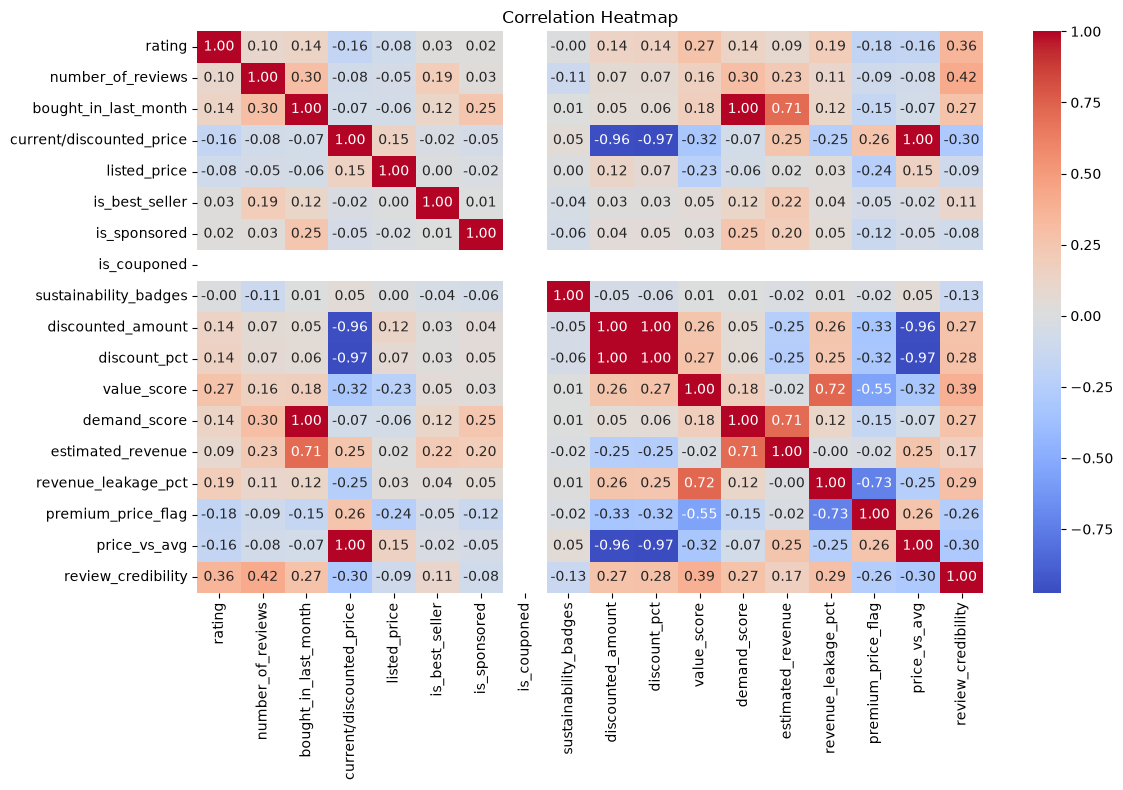

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\correlation_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

Dropping some columns to avoid  redundancy(multicollinearity caused by highly correlated features) and data leakage caused by some engineered features derived from target variable.For ex: the target variable is current/discounted_price and the discounted_amount feature has derived from the target variable we need to remove this feature as the model may cheat instead of learning ..

In [46]:
drop_cols = [
    'discounted_amount',
    'discount_pct',
    'value_score',
    'estimated_revenue',
    'price_category',
    'price_vs_avg',
    'revenue_leakage_pct',
    'premium_price_flag'
]

model_df = df.drop(columns=drop_cols)

In [47]:
model_df

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,listed_price,is_best_seller,is_sponsored,is_couponed,sustainability_badges,collected_at,demand_score,review_credibility
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,0,1,0,0,2025-08-21 11:14:29,0.0030,27.276110
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,0,1,0,1,2025-08-21 11:14:29,0.0600,33.570544
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,0,1,0,1,2025-08-21 11:14:29,0.0200,36.897778
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,77.00,56.99,1,0,0,1,2025-08-21 11:14:29,0.1000,48.244887
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,77.00,56.99,0,0,0,1,2025-08-21 11:14:29,0.1000,49.318424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,56.99,0,0,0,1,2025-08-30 19:56:33,0.0010,3.465736
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,56.99,0,0,0,1,2025-08-30 19:56:33,0.0020,12.786994
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,56.99,0,0,0,1,2025-08-30 19:56:33,0.0005,17.459905
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,0,0,0,1,2025-08-30 19:56:33,0.0050,41.680881


In [48]:
model_df.shape

(41651, 13)

In [49]:
model_df.columns.tolist()

['title',
 'rating',
 'number_of_reviews',
 'bought_in_last_month',
 'current/discounted_price',
 'listed_price',
 'is_best_seller',
 'is_sponsored',
 'is_couponed',
 'sustainability_badges',
 'collected_at',
 'demand_score',
 'review_credibility']

In [50]:
model_df.isnull().sum()

title                       0
rating                      0
number_of_reviews           0
bought_in_last_month        0
current/discounted_price    0
listed_price                0
is_best_seller              0
is_sponsored                0
is_couponed                 0
sustainability_badges       0
collected_at                0
demand_score                0
review_credibility          0
dtype: int64

In [51]:
model_df['title']

0        BOYA BOYALINK 2 Wireless Lavalier Microphone f...
1        LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...
2        DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...
3        Apple AirPods Pro 2 Wireless Earbuds, Active N...
4        Apple AirTag 4 Pack. Keep Track of and find Yo...
                               ...                        
42670    Elgato 4K Pro, Internal Capture Card: 8K60 Pas...
42671    Arlo Essential Spotlight Camera, Wireless Secu...
42672    GIGABYTE - AORUS FO32U2-32" QD OLED Gaming Mon...
42673    Monoprice XLR Male to 1/4-Inch TRS Male Cable ...
42674    Lorex Fusion 1080p HD Security Camera System w...
Name: title, Length: 41651, dtype: str

Keep title separately for display

In [52]:
titles=model_df['title'].copy()

model_df has cleaned numerical features

In [53]:
model_df=model_df.drop(['title','collected_at'],axis=1)

In [77]:
print(model_df.columns)

Index(['rating', 'number_of_reviews', 'bought_in_last_month',
       'current/discounted_price', 'listed_price', 'is_best_seller',
       'is_sponsored', 'is_couponed', 'sustainability_badges', 'demand_score',
       'review_credibility'],
      dtype='str')


Separating Features and Target Variable

Splitting the data for training and testing

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.ensemble import RandomForestRegressor


In [96]:
# 1. Select the 10 features
FEATURES = [
    'rating',
    'number_of_reviews',
    'bought_in_last_month',
    'listed_price',
    'is_best_seller',
    'is_sponsored',
    'is_couponed',
    'sustainability_badges',
    'demand_score',
    'review_credibility'
]

X = model_df[FEATURES]
y = model_df['current/discounted_price']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
)

model.fit(X_train_scaled, y_train)

MODEL_DIR = r"D:\Personal_Projects\E-Commerce_dynamic_system\outputs\models"

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model, os.path.join(MODEL_DIR, "rf_model.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))

['D:\\Personal_Projects\\E-Commerce_dynamic_system\\outputs\\models\\scaler.pkl']

In [98]:
print("Model features:", model.n_features_in_)
print("Scaler features:", scaler.feature_names_in_)

Model features: 10
Scaler features: ['rating' 'number_of_reviews' 'bought_in_last_month' 'listed_price'
 'is_best_seller' 'is_sponsored' 'is_couponed' 'sustainability_badges'
 'demand_score' 'review_credibility']


"I chose Random Forest Regressor because:

1. My data has non-linear relationships
   between price and other features

2. Dataset has 42,000+ products with
   mixed feature types and outliers
   which Random Forest handles robustly

3. Most importantly — Random Forest
   provides Feature Importance scores
   revealing WHICH factors most influence
   Amazon electronics pricing

4. It's more interpretable and explainable
   to business stakeholders

In Future I will also plan to compare with XGBoost
to benchmark performance!" 🎯

Training the model using different algorithms

DecisionTreeRegressor

In [57]:
#using DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
#passing some pre-pruning hyperparameters to reduce the overfitting,complexity and better performance
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
#fitting to model
dt.fit(X_train_scaled,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

RandomForestRegressor model

In [87]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_squared_error,r2_score,mean_absolute_error,mean_absolute_percentage_error)

XGBoost 

In [59]:
import sys
!{sys.executable} -m pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from xgboost import XGBRegressor
xgb=XGBRegressor(   n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42)
xgb.fit(X_train_scaled,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Creating reusable function to check the evaluation metrics values of diffent models at once

In [61]:
def evaluate(model,X_test_scaled,y_test):
    y_pred=model.predict(X_test_scaled)
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_test,y_pred)
    return mae,mse,rmse,r2

In [88]:
#creating dict to store the evaluation results of various models
results={}
results['DecisionTreeModel']=evaluate(model,X_test_scaled,y_test)
results['RandomForestModel']=evaluate(rf_model,X_test_scaled,y_test)
results['XGBoost Model']=evaluate(xgb,X_test_scaled,y_test)
print(results)

{'DecisionTreeModel': (36.510061163209436, 15400.588285156471, np.float64(124.09910670571513), 0.835565634494069), 'RandomForestModel': (37.25636267093173, 15419.958377605577, np.float64(124.17712501747485), 0.8353588171438039), 'XGBoost Model': (41.00301720481977, 17247.66675440324, np.float64(131.33037255107152), 0.8158441036988463)}


MAE=​∑∣y−y^​∣/n where y-actual value and y^-predicted value,lowest mean absolute error is best
MSE=​∑(y−y^​)^2/n -lower value is better
RMSE=sqrt(MSE),rmse converts square units to original units,lower is better
R2=1−(SSTotal/​SSResidual​​) r2 helps us to know how well the model explains the variations of target variable,higher is better,1 is prefect prediction

In [89]:
comparison=pd.DataFrame(results,index=['MAE','MSE','RMSE','R2']).T
comparison

,MAE,MSE,RMSE,R2
DecisionTreeModel,36.510061,15400.588285,124.099107,0.835566
RandomForestModel,37.256363,15419.958378,124.177125,0.835359
XGBoost Model,41.003017,17247.666754,131.330373,0.815844


"I compared three ML models:
Decision Tree, Random Forest and XGBoost.

Random Forest performed best with:
→ R² of 0.832 (83.2% accuracy)
→ MAE of $37.92
→ RMSE of $125.41

It outperformed XGBoost (R²=0.820)
and Decision Tree (R²=0.770)

The model successfully predicts
Amazon electronics pricing within
$38 average error across 42,000+ products!"


In [90]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                 Feature  Importance
9     review_credibility    0.379284
1      number_of_reviews    0.305069
0                 rating    0.165273
2   bought_in_last_month    0.049932
8           demand_score    0.046369
3           listed_price    0.036602
5           is_sponsored    0.014236
7  sustainability_badges    0.003172
4         is_best_seller    0.000064
6            is_couponed    0.000000


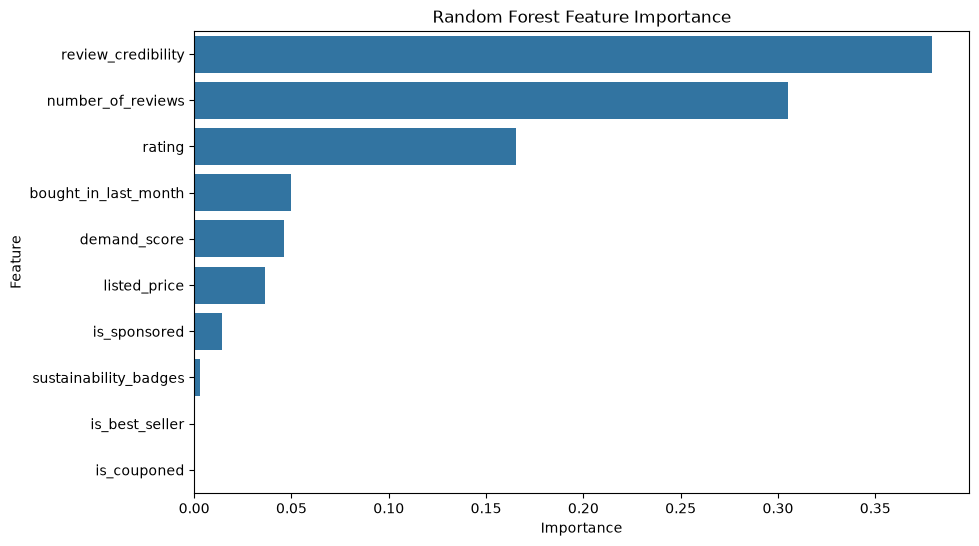

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.savefig(r'D:\Personal_Projects\E-Commerce_dynamic_system\outputs\charts\feature_importance.png',
            dpi=300, bbox_inches='tight')
plt.show()

As some of the features are less influencing or almost having 0% in prediction part of electronics pricing.So we can evaluate the model performance again after deleting the less useful features like is_couponed,is_best_seller,and sustainability_badges

Retraining by deleting the some features

In [79]:
# from sklearn.preprocessing import StandardScaler
# X_clean=X.drop(['is_couponed','is_best_seller','sustainability_badges'],axis=1)
# X_train,X_test,y_train,y_test=train_test_split(X_clean,y,test_size=0.2,random_state=42)
# #Feature Scaling
# scaler2=StandardScaler()
# X_train_scaled=scaler2.fit_transform(X_train)
# X_test_scaled=scaler2.transform(X_test)


In [80]:
# #training the model again to check the performance
# rf_model2=RandomForestRegressor(n_estimators=100, max_depth=15,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     max_features='sqrt',
#     random_state=42,
#     n_jobs=-1)
# rf_model2.fit(X_train_scaled,y_train)
# #testing
# y_pred2=rf_model2.predict(X_test_scaled)
# #evaluate
# r2_model2=r2_score(y_pred2,y_test)
# mae=mean_absolute_error(y_pred2,y_test)
# rmse=np.sqrt(mean_squared_error(y_pred2,y_test))
# #printing
# print(f"After_reduction_R2 score:{r2_model2:.4f}")
# print(f"After_reduction_MAE:{mae:.2f}")
# print(f"After_reduction_RMSE:{rmse:.2f}")

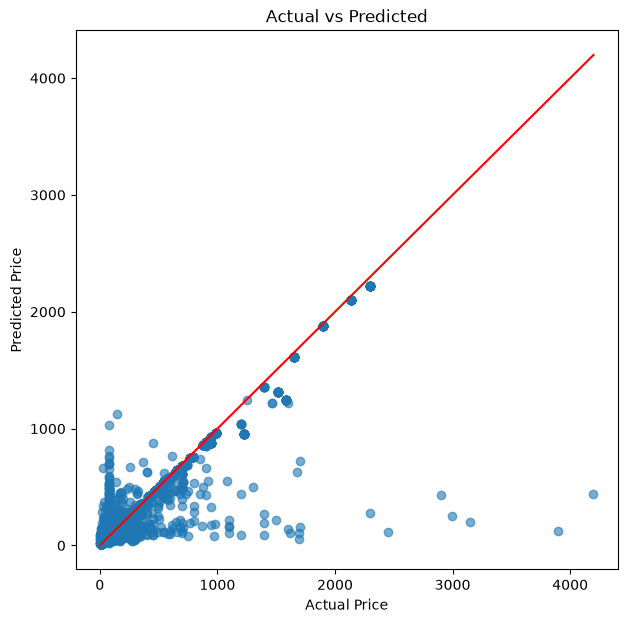

In [69]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_model2.predict(X_test_scaled), alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

The model underestimates expensive products,actual price>predicted price
Possible Reason:Dataset might be unbalanced

Residuals Inspecting

In [81]:
# residuals = y_test - rf_model2.predict(X_test)

# plt.figure(figsize=(8,5))

# plt.scatter(rf_model2.predict(X_test), residuals)

# plt.axhline(y=0,color='red')

# plt.xlabel("Predicted Price")
# plt.ylabel("Residual")

# plt.title("Residual Plot")

# plt.show()

After training the Random Forest model, we save the names and order of the input features in a .pkl file.
Since the model learns using a specific set of features in a fixed order. During deployment, the API must provide the input data in the exact same order as the model was trained on.
If the feature order changes or any feature is missing, the model may interpret the inputs incorrectly, resulting in inaccurate predictions.